# PCA for dimensionality reduction on Salinity, Temperature and Oxygen (STO) data - GMM clustering

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import plotly.express as px
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
# Scale data
scaler = StandardScaler()
scaled_ST = scaler.fit_transform(df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Depth_[m]']])

In [5]:
# Use PCA to reduce dimensionality
pca = PCA(n_components=2)  # 2 principal components
X_pca = pca.fit_transform(scaled_ST)

In [6]:
# How much variance is explained by each component
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each component: {explained_variance}')

Explained variance by each component: [0.49683915 0.39653866]


Text(0, 0.5, 'Principal Component 2')

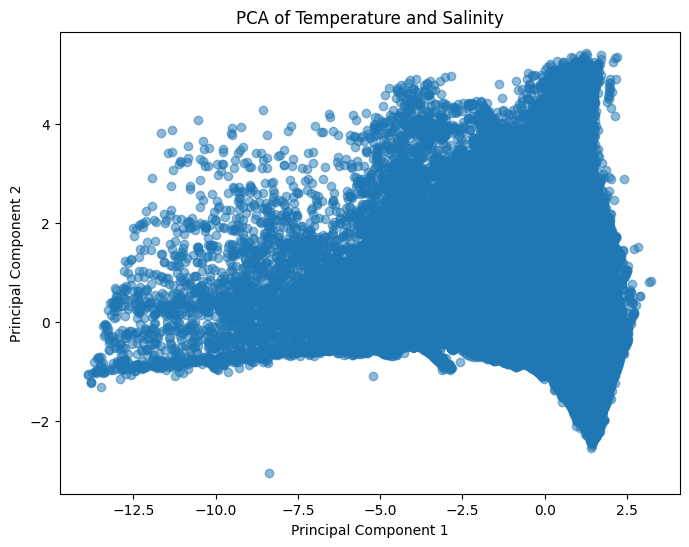

In [7]:
# Plot pca space
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA of Temperature and Salinity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [8]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

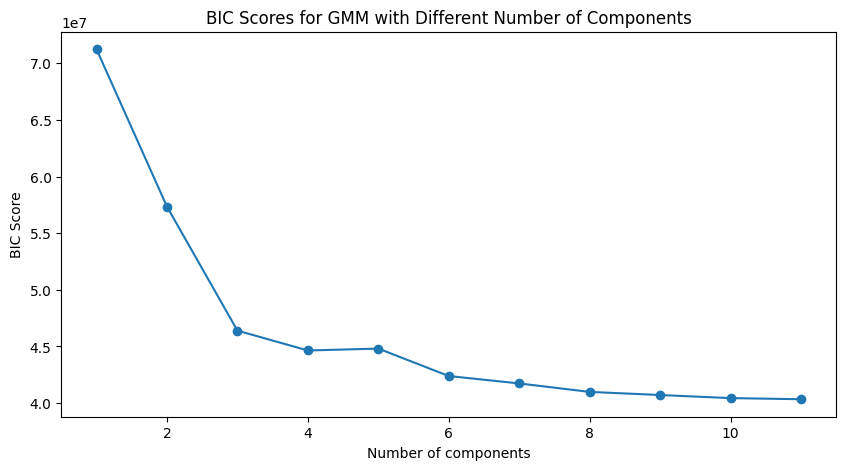

In [9]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [22]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 8

In [23]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_pca)

In [24]:
df_ST['gmm_label'] = labels

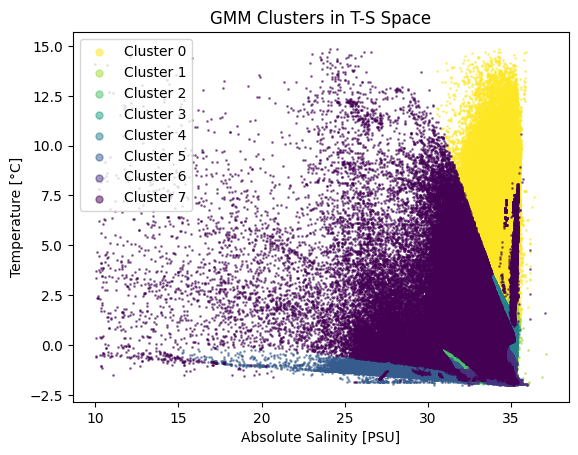

In [25]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_ST['gmm_label'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [26]:
# Sample for plotting ease
df_sampled = df_ST.sample(n=100000, random_state=seed)

In [27]:
# Compute data centroid (mean location)
center_lat = df_ST['Latitude_[deg_N]'].mean()
center_lon = df_ST['Longitude_[deg_E]'].mean()

colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma, # Colour scale same as continuous colour bar version but sampled to be discrete
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="GMM clusters using TSO on geographic map"
)

fig.update_traces(
    marker=dict(size=5, opacity=0.9)
)

fig.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig.add_trace(
        go.Scattergeo(
            lat=[None], lon=[None],   # invisible
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig.update_layout(
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig.show()

In [45]:
# Plot in 3D
colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma,
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="3D Scatter Lat-Lon-Depth plot of GMM clusters"
)

fig_3d.update_traces(
    marker=dict(
        size=5
    )
)

fig_3d.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig_3d.add_trace(
        go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Latitude',
        yaxis_title='Longitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')
    ),
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig_3d.show()

In [36]:
def cross_sec_lon(lon_value, tol=0.5):
    df_lon_slice = df_ST[
        (df_ST['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_ST['Longitude_[deg_E]'] <= lon_value + tol)
    ]

    n = optimal_n_components

    # Sample full sequential colormap discretely
    base_cmap = plt.cm.viridis
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)

    # Discrete normalization
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    plt.gca().invert_yaxis()
    plt.xlabel('Latitude [deg N]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Latitude-Depth Cross Section at Longitude ~ {lon_value}°E')

    # ---- Discrete legend (dummy handles) ----
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=colors[i],
            markeredgecolor='none',
            label=f'Cluster {i}'
        )
        for i in range(n)
    ]

    plt.legend(
        handles=handles,
        title='GMM Cluster',
        loc='lower left',
    )

    plt.tight_layout()
    plt.show()

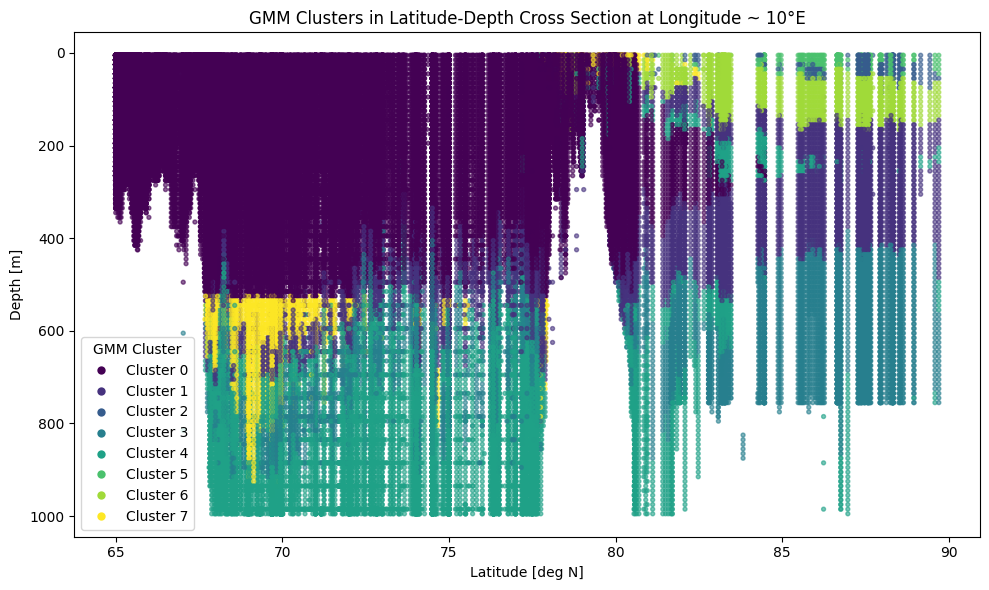

In [37]:
# Plot cross section for specific longitude slice
lon_val= 10
cross_sec_lon(lon_val, tol=0.5)

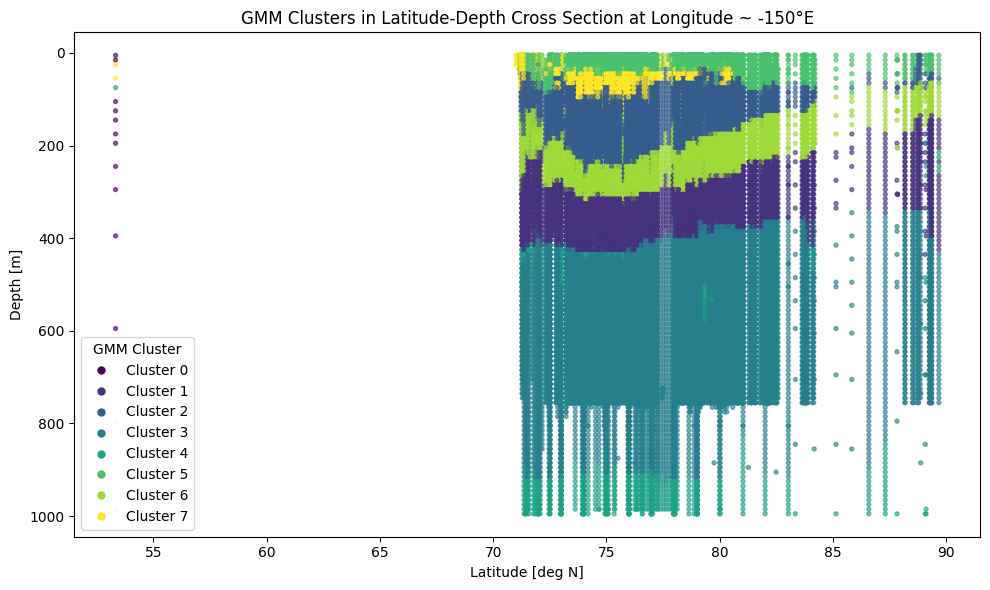

In [38]:
lat_val= -150
cross_sec_lon(lat_val, tol=0.5)

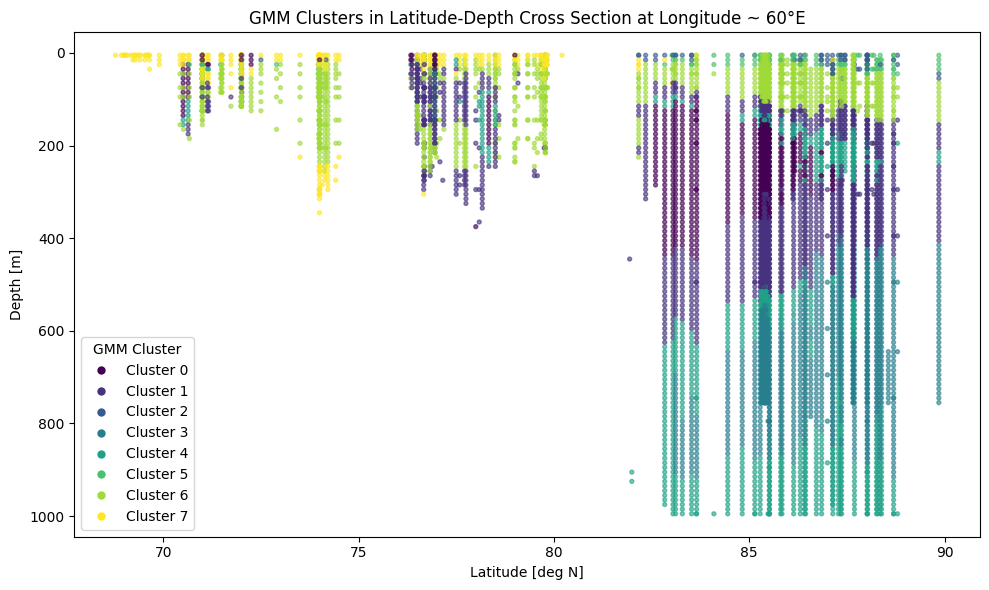

In [44]:
lat = 60
cross_sec_lon(lat, tol=0.5)

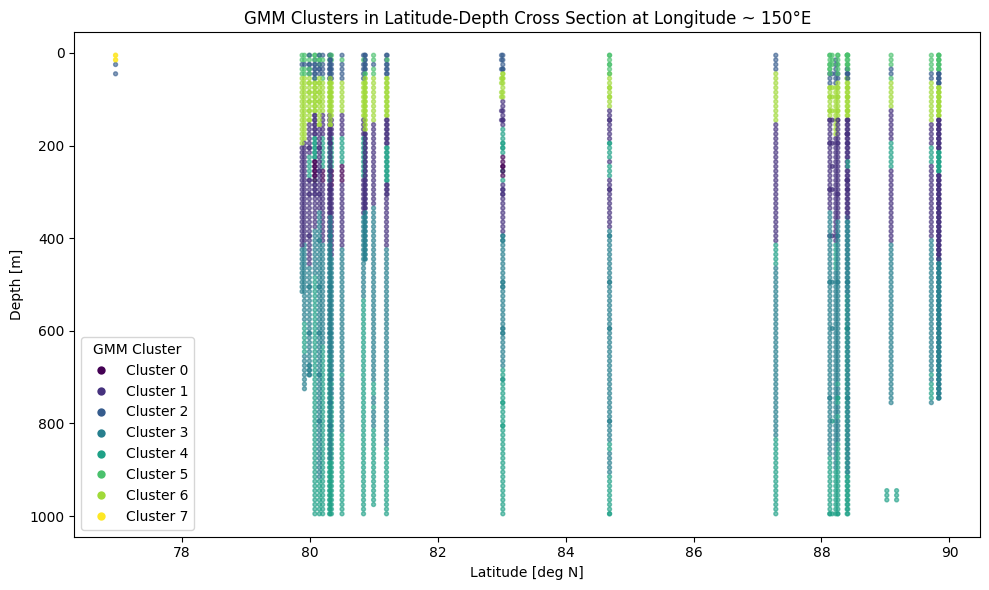

In [46]:
lon = 150
cross_sec_lon(lon, tol=0.5)

In [33]:
# Loss of information
reconstructed_data = pca.inverse_transform(X_pca)
mse = np.mean((scaled_ST - reconstructed_data) ** 2)
print(f'Mean Squared Error of PCA reconstruction: {mse}')

Mean Squared Error of PCA reconstruction: 0.10662218813040499
